**PPCA al Análisis Factorial Probabilístico**

**Curso:** Estadística Multivariable Aplicada para Ciencia de Datos  
**Tema:** Factor Analysis como extensión probabilística de PPCA.  
**Continuidad:** esta sesión parte de PCA y PPCA, y avanza hacia un modelo latente más flexible en el que cada variable observada puede tener su propio nivel de ruido.

## Objetivo general

Entender el **Análisis Factorial probabilístico** como una extensión natural de PPCA, comparar sus supuestos con PCA y PPCA, y analizar sus ventajas cuando las variables observadas tienen diferentes niveles de confiabilidad o ruido.

## Objetivos específicos

Al finalizar la sesión, el estudiante debería poder:

1. Reconocer la diferencia conceptual entre PCA, PPCA y Factor Analysis.
2. Identificar por qué PPCA puede ser restrictivo cuando todas las variables no tienen el mismo nivel de ruido.
3. Ajustar PCA, PPCA y Factor Analysis sobre un conjunto de datos simulado.
4. Comparar cargas, scores latentes, covarianzas estimadas y errores de reconstrucción.
5. Interpretar las ventajas del Análisis Factorial en términos de variables latentes, comunalidad y ruido específico.

In [1]:
# @title Importaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import eigh
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Puente conceptual: PCA, PPCA y Factor Analysis

En PCA trabajamos con una matriz de datos

$$
X \in \mathbb{R}^{n \times p},
$$

donde $n$ es el número de observaciones y $p$ es el número de variables observadas.

PCA busca nuevas variables, llamadas componentes principales, que son combinaciones lineales de las variables originales. Su objetivo central es geométrico:

> encontrar direcciones ortogonales donde los datos presentan la mayor varianza.

En PPCA cambiamos la mirada. Ya no pensamos solamente en direcciones geométricas, sino en un modelo generativo:

$$
x = Wz + \mu + \varepsilon,
$$

con

$$
z \sim N(0,I_k), \qquad \varepsilon \sim N(0,\sigma^2 I_p).
$$

Aquí $z$ representa factores latentes no observados y $\varepsilon$ representa ruido. La restricción clave de PPCA es que el ruido tiene la misma varianza en todas las variables observadas.

Factor Analysis mantiene la misma idea generativa, pero relaja esa restricción:

$$
x = Wz + \mu + \varepsilon,
$$

con

$$
z \sim N(0,I_k), \qquad \varepsilon \sim N(0,\Psi),
$$

donde

$$
\Psi = \operatorname{diag}(\psi_1,\psi_2,\ldots,\psi_p).
$$

Es decir, cada variable observada puede tener su propia varianza de ruido.

## 2. ¿Qué problema deja abierto PPCA?

PPCA supone que todas las variables tienen ruido con la misma intensidad:

$$
\operatorname{Var}(\varepsilon_j)=\sigma^2, \qquad j=1,\ldots,p.
$$

Este supuesto puede ser razonable en algunos contextos, pero puede ser demasiado fuerte en aplicaciones reales.

Por ejemplo, algunas variables pueden medirse con alta precisión, mientras que otras pueden ser subjetivas, agregadas, inestables o más contaminadas por error.

Factor Analysis permite modelar esta situación mediante

$$
\operatorname{Var}(\varepsilon_j)=\psi_j.
$$

Por tanto, el modelo separa dos fuentes de variabilidad:

1. **variabilidad común**, explicada por los factores latentes;
2. **variabilidad específica**, propia de cada variable observada.

## 3. Ejemplo conductor: bienestar urbano y movilidad sostenible

Usaremos un ejemplo sintético, pero realista, diferente al de las sesiones anteriores.

Suponga que una ciudad está construyendo un índice multivariado de bienestar urbano por zonas. Para cada zona se observan seis indicadores:

1. $x_1$: acceso a transporte público;
2. $x_2$: calidad del aire;
3. $x_3$: tiempo promedio de desplazamiento;
4. $x_4$: disponibilidad de zonas verdes;
5. $x_5$: percepción de seguridad;
6. $x_6$: actividad comercial local.

La hipótesis es que estas seis variables están influenciadas por dos dimensiones latentes:

- $z_1$: conectividad urbana;
- $z_2$: calidad ambiental y social.

Sin embargo, no todas las variables tienen el mismo nivel de ruido. Por ejemplo, la percepción de seguridad puede ser más ruidosa que el acceso a transporte público, porque depende de encuestas, contexto subjetivo y variabilidad temporal.

In [2]:
# @title Simulación del ejemplo conductor

rng = np.random.default_rng(2026)

n = 900
p = 6
k_real = 2

# Factores latentes reales
# z1: conectividad urbana
# z2: calidad ambiental y social
Z_real = rng.normal(size=(n, k_real))

# Matriz de cargas verdadera
# Filas: variables observadas
# Columnas: factores latentes
W_real = np.array([
    [1.25,  0.10],   # acceso a transporte público
    [0.15,  1.10],   # calidad del aire
    [-1.05, -0.25],  # tiempo de desplazamiento, menor es mejor
    [0.20,  1.25],   # zonas verdes
    [0.40,  0.85],   # percepción de seguridad
    [0.95,  0.35],   # actividad comercial local
])

# Ruido específico por variable
# Esta es la diferencia central frente a PPCA.
psi_real = np.array([0.15, 0.25, 0.30, 0.20, 0.85, 0.45])
E = rng.normal(scale=np.sqrt(psi_real), size=(n, p))

mu_real = np.array([65, 70, 45, 55, 50, 60])
X = mu_real + Z_real @ W_real.T + E

columnas = [
    "transporte_publico",
    "calidad_aire",
    "tiempo_desplazamiento",
    "zonas_verdes",
    "percepcion_seguridad",
    "actividad_comercial"
]

df = pd.DataFrame(X, columns=columnas)
df.head()

,transporte_publico,calidad_aire,tiempo_desplazamiento,zonas_verdes,percepcion_seguridad,actividad_comercial
0,64.555537,70.101759,46.231246,55.011892,49.947638,58.592511
1,61.945405,71.023253,46.677626,56.136353,50.895021,58.125637
2,65.213924,69.017213,44.738624,54.372778,49.970970,59.523279
3,64.284010,70.247927,45.809221,54.811251,48.733683,59.754845
4,64.674487,69.457635,45.964242,53.861466,48.870493,59.614708


In [3]:
# @title Resumen descriptivo

df.describe().T

,count,mean,std,min,25%,50%,75%,max
transporte_publico,900.0,64.999938,1.310410,59.887902,64.109851,65.016526,65.908318,69.276446
calidad_aire,900.0,69.962998,1.239628,66.254117,69.130683,70.009748,70.822776,74.332291
tiempo_desplazamiento,900.0,45.003905,1.250089,40.840536,44.161551,44.941261,45.874225,49.107022
zonas_verdes,900.0,54.941827,1.369691,50.768342,54.043871,54.984116,55.874333,59.501282
percepcion_seguridad,900.0,49.974543,1.364257,45.618515,49.027404,49.990770,50.894048,54.643919
actividad_comercial,900.0,59.983951,1.242190,56.234900,59.125747,60.034871,60.773256,64.028282


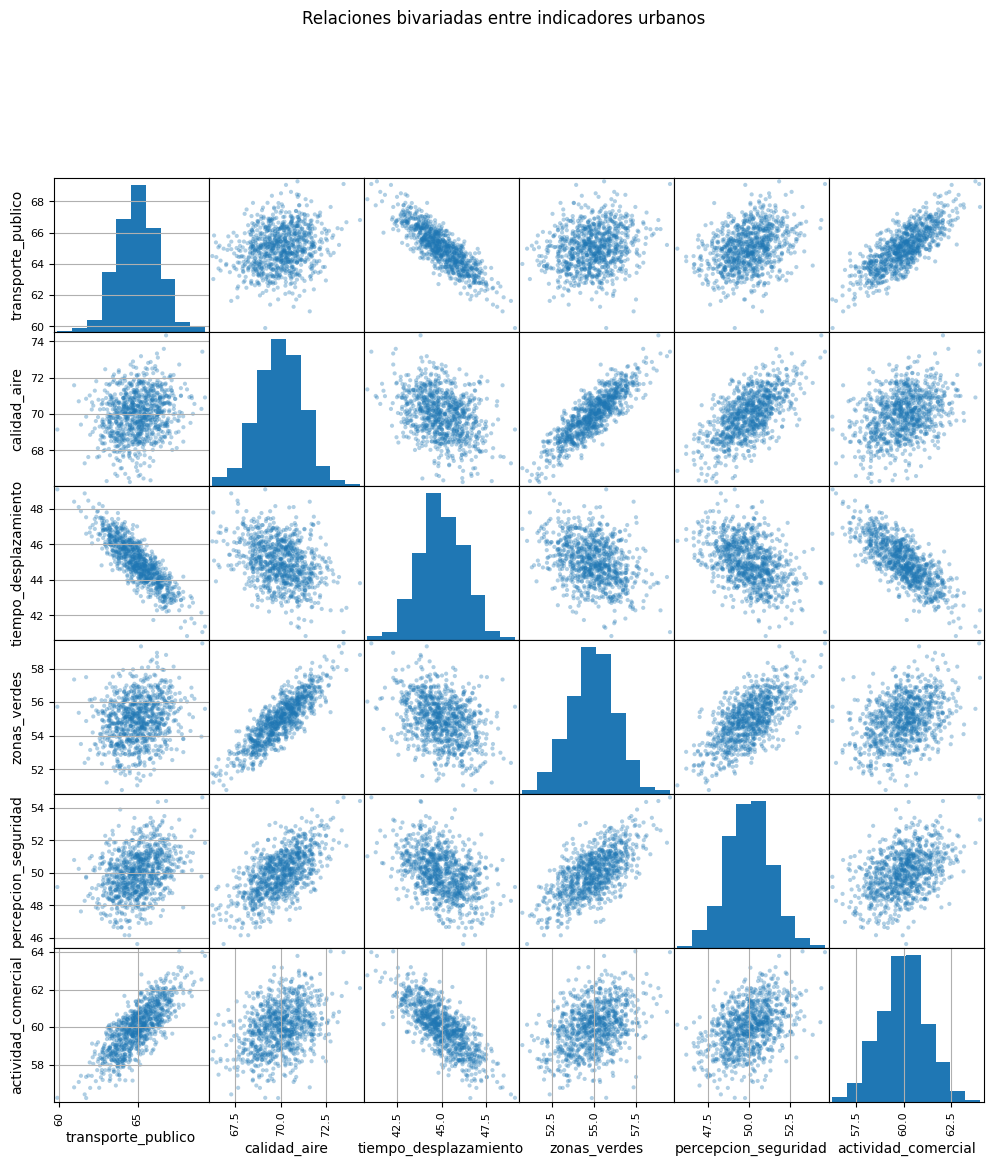

In [4]:
# @title Visualización inicial de relaciones entre variables

pd.plotting.scatter_matrix(df, figsize=(12, 12), diagonal="hist", alpha=0.35)
plt.suptitle("Relaciones bivariadas entre indicadores urbanos", y=1.02)
plt.show()

### Lectura inicial

Antes de ajustar modelos, la matriz de dispersión permite observar que varias variables no se comportan de manera aislada. Hay relaciones bivariadas claras: por ejemplo, `transporte_publico` y `actividad_comercial` se mueven positivamente, mientras que `transporte_publico` y `tiempo_desplazamiento` muestran una relación negativa. Esto sugiere la presencia de factores latentes comunes asociados con conectividad urbana, movilidad y dinamismo territorial.

La tabla descriptiva muestra que las desviaciones estándar de las variables son relativamente parecidas. Por tanto, no sería correcto afirmar únicamente desde esta tabla que una variable tiene mucho más ruido que otra. Esa separación no la entrega el resumen descriptivo.

La ventaja del Análisis Factorial aparece precisamente después: permite descomponer la variabilidad de cada variable en una parte común, explicada por los factores latentes, y una parte específica, propia de cada indicador. Por eso, si una variable como `percepcion_seguridad` resulta más subjetiva o menos estable, esto debería evidenciarse posteriormente en una menor comunalidad o en una mayor unicidad estimada por el modelo, no necesariamente en su desviación estándar marginal.

## 4. Estandarización de los datos

Como las variables están en escalas distintas, trabajaremos con datos estandarizados:

$$
X_{std,j}=\frac{X_j-\bar X_j}{s_j}.
$$

Esto permite comparar modelos sin que una variable domine por tener mayor escala numérica.

In [5]:
# @title Estandarización

scaler = StandardScaler()
X_std = scaler.fit_transform(df)

X_std_df = pd.DataFrame(X_std, columns=columnas)
X_std_df.describe().T

,count,mean,std,min,25%,50%,75%,max
transporte_publico,900.0,5.711185e-14,1.000556,-3.903267,-0.679621,0.012666,0.693589,3.265304
calidad_aire,900.0,6.710681e-14,1.000556,-2.993594,-0.671797,0.037734,0.693963,3.526640
tiempo_desplazamiento,900.0,3.387710e-14,1.000556,-3.332311,-0.674210,-0.050139,0.696594,3.284086
zonas_verdes,900.0,-1.485429e-14,1.000556,-3.048720,-0.655954,0.030893,0.681194,3.330670
percepcion_seguridad,900.0,-1.404704e-14,1.000556,-3.194743,-0.694639,0.011901,0.674372,3.424555
actividad_comercial,900.0,-5.329071e-16,1.000556,-3.019777,-0.691264,0.041014,0.635767,3.257618


## 5. PCA aplicado al ejemplo

Recordemos que PCA busca una representación de baja dimensión que preserve la mayor cantidad posible de variabilidad presente en los datos.

Si $X \in \mathbb{R}^{n \times p}$ representa la matriz de datos estandarizada, entonces la matriz de covarianzas puede escribirse como

$$
S = \frac{1}{n}X^TX.
$$

PCA construye una descomposición espectral de la forma

$$
S = Q \Lambda Q^T,
$$

donde:

- $Q = [q_1,\dots,q_p]$ contiene los autovectores ortonormales,
- $\Lambda = \text{diag}(\lambda_1,\dots,\lambda_p)$ contiene los autovalores ordenados.

Las primeras componentes principales corresponden a las direcciones asociadas con los mayores autovalores.

Si retenemos únicamente las primeras $k$ componentes, obtenemos la aproximación

$$
X \approx Z_k Q_k^T,
$$

donde

$$
Z_k = XQ_k
$$

corresponde a los scores proyectados sobre el subespacio principal generado por las primeras $k$ direcciones principales.

En este enfoque, PCA describe la estructura dominante de variabilidad en los datos, pero no separa explícitamente la variabilidad común de la variabilidad específica o del ruido propio de cada variable.

In [6]:
# @title Ajuste de PCA

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_std)

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=columnas,
    columns=["PC1", "PC2"]
)

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)
print("\nVarianza explicada acumulada:")
print(pca.explained_variance_ratio_.sum())

pca_loadings

Varianza explicada por componente:
[0.5868 0.2591]

Varianza explicada acumulada:
0.8458912819076869


,PC1,PC2
transporte_publico,-0.399106,-0.474510
calidad_aire,-0.383480,0.477817
tiempo_desplazamiento,0.439227,0.360912
zonas_verdes,-0.390317,0.475323
percepcion_seguridad,-0.397096,0.297952
actividad_comercial,-0.436698,-0.318694


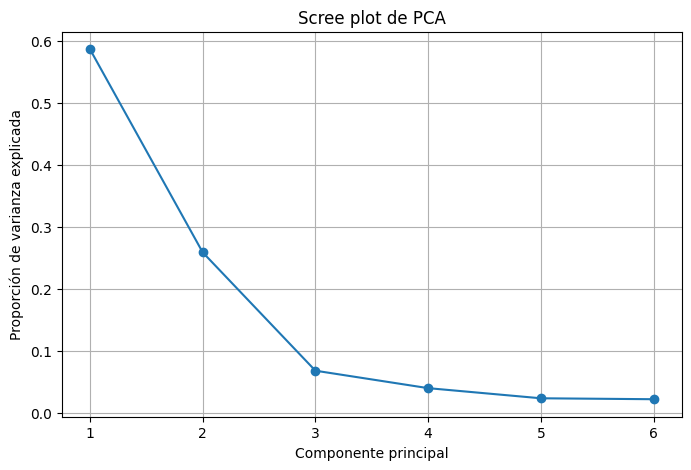

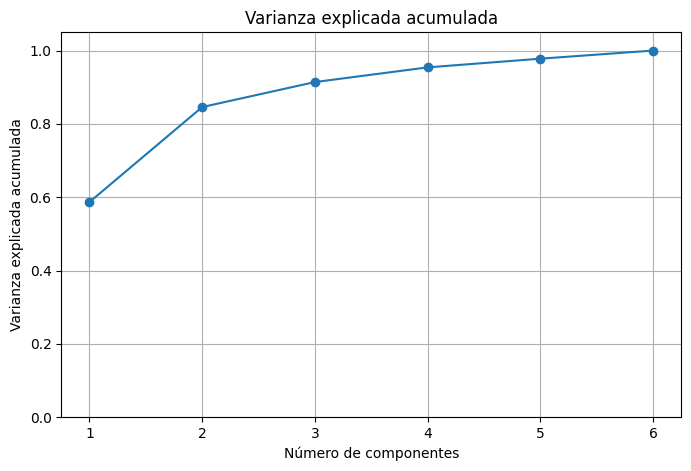

In [7]:
# @title Scree plot de PCA

pca_full = PCA().fit(X_std)

plt.figure()
plt.plot(np.arange(1, p + 1), pca_full.explained_variance_ratio_, marker="o")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.title("Scree plot de PCA")
plt.xticks(np.arange(1, p + 1))
plt.show()

plt.figure()
plt.plot(np.arange(1, p + 1), np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada")
plt.xticks(np.arange(1, p + 1))
plt.ylim(0, 1.05)
plt.show()

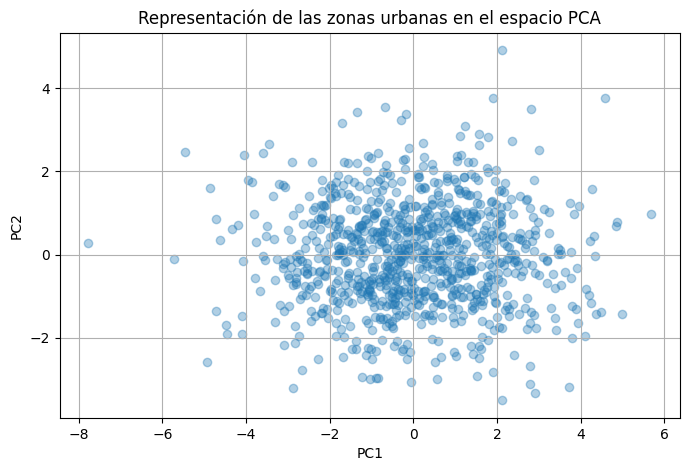

In [8]:
# @title Scores PCA

plt.figure()
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Representación de las zonas urbanas en el espacio PCA")
plt.show()

## 6. Recordatorio de PPCA

PPCA introduce una interpretación probabilística de PCA mediante el modelo

$$
x = \mu + Wz + \varepsilon,
$$

donde:

- $x \in \mathbb{R}^p$ representa una observación,
- $z \in \mathbb{R}^k$ corresponde a las variables latentes,
- $W \in \mathbb{R}^{p \times k}$ es la matriz de cargas,
- $\varepsilon$ representa el término de ruido.

El modelo asume

$$
z \sim N(0,I_k),
\qquad
\varepsilon \sim N(0,\sigma^2 I_p).
$$

Bajo estas hipótesis, la distribución marginal de $x$ es

$$
x \sim N(\mu,C),
$$

con matriz de covarianza

$$
C = WW^T + \sigma^2 I_p.
$$

Por tanto, PPCA modela la estructura de dependencia mediante una parte de baja dimensión, $WW^T$, y un término de ruido isotrópico, $\sigma^2 I_p$.

La principal ventaja frente a PCA es que PPCA proporciona una interpretación probabilística y generativa del modelo. Sin embargo, mantiene una restricción importante: todas las variables comparten el mismo nivel de ruido específico.

In [9]:
# @title Estimación cerrada de PPCA a partir de la matriz de covarianza

S = np.cov(X_std, rowvar=False)

# Descomposición espectral
vals, vecs = eigh(S)
idx = vals.argsort()[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

k = 2
lambda_k = vals[:k]
U_k = vecs[:, :k]

# Estimador de sigma^2 en PPCA
sigma2_hat = vals[k:].mean()

# Una elección de W_hat, sin rotación adicional
W_ppca = U_k @ np.diag(np.sqrt(np.maximum(lambda_k - sigma2_hat, 0)))
C_ppca = W_ppca @ W_ppca.T + sigma2_hat * np.eye(p)

ppca_loadings = pd.DataFrame(W_ppca, index=columnas, columns=["Factor_1_PPCA", "Factor_2_PPCA"])

print("Sigma^2 estimado en PPCA:", round(sigma2_hat, 4))
ppca_loadings

Sigma^2 estimado en PPCA: 0.2314


,Factor_1_PPCA,Factor_2_PPCA
transporte_publico,-0.724264,-0.546193
calidad_aire,-0.695907,0.550000
tiempo_desplazamiento,0.797072,0.415435
zonas_verdes,-0.708314,0.547129
percepcion_seguridad,-0.720616,0.342963
actividad_comercial,-0.792483,-0.366839


## 7. Factor Analysis: el siguiente modelo natural

Factor Analysis conserva la estructura latente:

$$
x = Wz + \mu + \varepsilon,
$$

pero cambia el supuesto sobre el ruido:

$$
\varepsilon \sim N(0,\Psi),
$$

con

$$
\Psi = \operatorname{diag}(\psi_1,\psi_2,\ldots,\psi_p).
$$

La distribución marginal de $x$ es

$$
x \sim N(\mu, WW^T + \Psi).
$$

Así, la matriz de covarianza modelada es

$$
C_{FA}=WW^T+\Psi.
$$

La diferencia con PPCA es fundamental:

$$
C_{PPCA}=WW^T+\sigma^2 I_p,
$$

mientras que

$$
C_{FA}=WW^T+\Psi.
$$

En PPCA todas las variables comparten el mismo ruido. En Factor Analysis cada variable tiene su propio ruido específico.

## 8. Interpretación: comunalidad y unicidad

En Factor Analysis, la varianza de cada variable se descompone en dos partes:

$$
\operatorname{Var}(x_j)=h_j^2+\psi_j,
$$

donde:

- $h_j^2$ es la **comunalidad** de la variable $j$;
- $\psi_j$ es la **unicidad** o varianza específica de la variable $j$.

La comunalidad mide qué tanto de la variabilidad de una variable es explicada por los factores comunes.

Si los datos están estandarizados, aproximadamente:

$$
h_j^2 + \psi_j \approx 1.
$$

Una variable con alta unicidad tiene mucha variación propia no explicada por los factores comunes. En un buen modelo factorial, se espera que las variables centrales del fenómeno tengan unicidades relativamente bajas y comunalidades altas. Una unicidad elevada puede indicar ruido, medición imprecisa, subjetividad o información específica no compartida con las demás variables.

In [10]:
# @title Ajuste de Factor Analysis

fa = FactorAnalysis(n_components=2, random_state=2026)
Z_fa = fa.fit_transform(X_std)

# En sklearn, components_ tiene forma (n_components, n_features)
W_fa = fa.components_.T
psi_fa = fa.noise_variance_
C_fa = W_fa @ W_fa.T + np.diag(psi_fa)

fa_loadings = pd.DataFrame(W_fa, index=columnas, columns=["Factor_1_FA", "Factor_2_FA"])
fa_noise = pd.DataFrame({"unicidad_psi": psi_fa}, index=columnas)

fa_loadings

,Factor_1_FA,Factor_2_FA
transporte_publico,0.795166,-0.519541
calidad_aire,0.659605,0.623940
tiempo_desplazamiento,-0.839363,0.352815
zonas_verdes,0.682181,0.650171
percepcion_seguridad,0.641138,0.332725
actividad_comercial,0.805322,-0.273142


In [11]:
# @title Unicidades estimadas por Factor Analysis

fa_noise.sort_values("unicidad_psi", ascending=False)

,unicidad_psi
percepcion_seguridad,0.478196
actividad_comercial,0.276807
calidad_aire,0.175313
tiempo_desplazamiento,0.170873
zonas_verdes,0.112258
transporte_publico,0.097968


In [12]:
# @title Comunalidades estimadas

communalities = np.sum(W_fa**2, axis=1)
communalities_df = pd.DataFrame(
    {
        "comunalidad_h2": communalities,
        "unicidad_psi": psi_fa,
        "suma_aprox": communalities + psi_fa
    },
    index=columnas
)

communalities_df.sort_values("unicidad_psi", ascending=False)

,comunalidad_h2,unicidad_psi,suma_aprox
percepcion_seguridad,0.521763,0.478196,0.999959
actividad_comercial,0.723149,0.276807,0.999956
calidad_aire,0.824379,0.175313,0.999692
tiempo_desplazamiento,0.829009,0.170873,0.999881
zonas_verdes,0.888093,0.112258,1.000352
transporte_publico,0.902212,0.097968,1.000181


### Interpretación de comunalidades y unicidades

La tabla muestra que el modelo factorial logra representar adecuadamente la mayoría de las variables mediante los factores comunes estimados.

Como los datos fueron estandarizados, se espera que para cada variable se cumpla aproximadamente:

$$
h_j^2+\psi_j \approx 1.
$$

Esto se observa en la columna `suma_aprox`, cuyos valores son muy cercanos a 1. Por tanto, la descomposición entre varianza común y varianza específica es coherente.

Las variables mejor explicadas por la estructura factorial son `transporte_publico`, `zonas_verdes`, `tiempo_desplazamiento` y `calidad_aire`, con comunalidades superiores a 0.82. Esto significa que más del 82% de su variabilidad queda explicada por los factores latentes comunes.

En particular, `transporte_publico` presenta la mayor comunalidad, cercana a 0.90, y la menor unicidad, cercana a 0.10. Esto indica que esta variable está fuertemente integrada en la estructura latente del modelo.

Por el contrario, `percepcion_seguridad` tiene la menor comunalidad, aproximadamente 0.52, y la mayor unicidad, aproximadamente 0.48. Esto no significa que la variable sea inútil, sino que casi la mitad de su variabilidad corresponde a información específica no explicada por los factores comunes. Esto es consistente con una variable más subjetiva, más local o más sensible a percepciones individuales.

Finalmente, `actividad_comercial` ocupa una posición intermedia, con una comunalidad cercana a 0.72 y una unicidad cercana a 0.28. El modelo la explica razonablemente bien, aunque conserva una parte específica mayor que variables como `transporte_publico` o `zonas_verdes`.

En síntesis, el Análisis Factorial permite ver algo que PCA y PPCA no muestran de forma tan directa: no todas las variables son igualmente explicadas por el mundo latente común. Algunas variables están fuertemente alineadas con la estructura factorial, mientras que otras conservan una mayor componente específica.

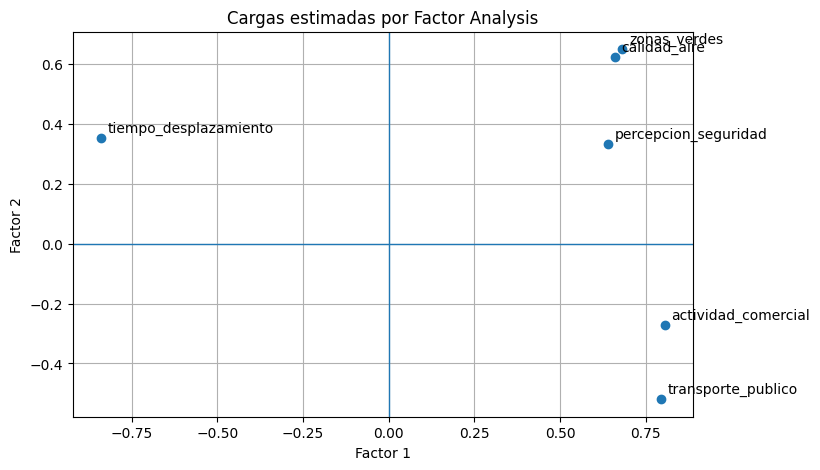

In [13]:
# @title Visualización de cargas factoriales

plt.figure()
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.scatter(W_fa[:, 0], W_fa[:, 1])

for i, var in enumerate(columnas):
    plt.text(W_fa[i, 0] + 0.02, W_fa[i, 1] + 0.02, var)

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Cargas estimadas por Factor Analysis")
plt.show()

### Interpretación del espacio factorial

La gráfica muestra cómo cada variable se proyecta sobre los dos factores latentes estimados por el modelo.

Variables cercanas entre sí tienden a compartir una estructura común similar. Por ejemplo, `calidad_aire` y `zonas_verdes` aparecen muy próximas, lo que sugiere que ambas están fuertemente asociadas con un mismo componente latente relacionado con bienestar urbano y entorno ambiental.

`transporte_publico` y `actividad_comercial` también presentan cargas importantes sobre el primer factor, aunque con comportamientos distintos sobre el segundo eje.

Por otra parte, `tiempo_desplazamiento` aparece separado del grupo principal sobre el Factor 1, indicando una relación estructural diferente respecto a las demás variables.

Finalmente, `percepcion_seguridad` ocupa una posición más intermedia y menos extrema dentro del espacio factorial, consistente con la idea de que parte de su variabilidad no es completamente explicada por los factores comunes del modelo.

### Lectura del modelo factorial

El Factor Analysis intenta encontrar factores comunes que expliquen la dependencia entre variables, pero no fuerza a que todas las variables tengan el mismo ruido.

En este ejemplo, si una variable aparece con alta unicidad, el modelo está diciendo:

> esta variable contiene una parte importante de variación específica que no se explica bien con los factores comunes.

Esto es una ventaja frente a PPCA cuando las variables tienen diferente confiabilidad.

## 9. Comparación de matrices de covarianza estimadas

Compararemos la matriz de covarianza muestral con las matrices estimadas por PPCA y Factor Analysis.

La matriz muestral es

$$
S = \frac{1}{n-1}X_{std}^T X_{std}.
$$

PPCA aproxima $S$ mediante

$$
\hat C_{PPCA}=\hat W\hat W^T+\hat\sigma^2 I_p.
$$

Factor Analysis aproxima $S$ mediante

$$
\hat C_{FA}=\hat W\hat W^T+\hat\Psi.
$$

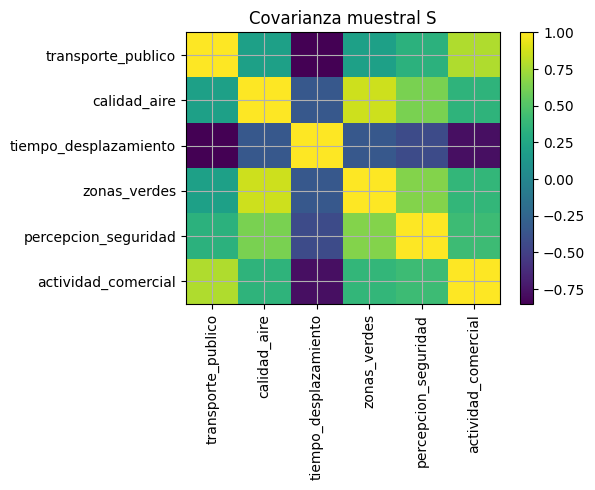

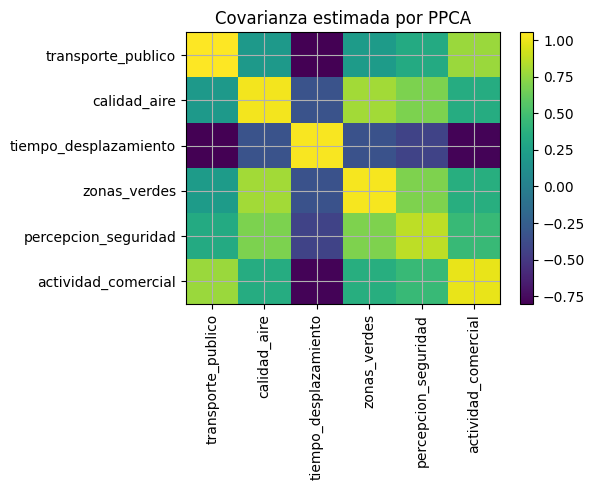

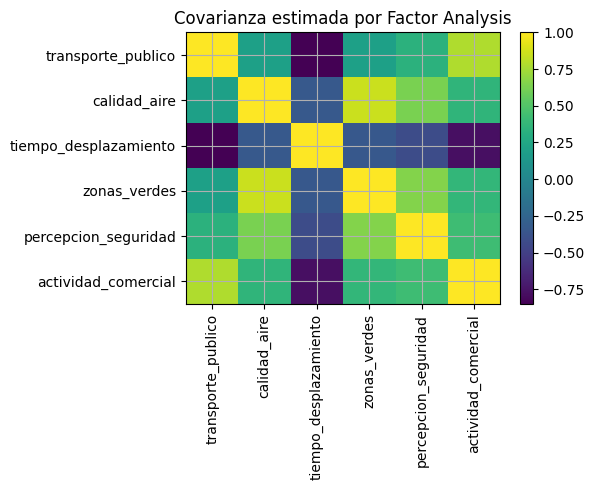

In [14]:
# @title Función auxiliar para graficar mapas de calor

def heatmap_matrix(M, title, labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

heatmap_matrix(S, "Covarianza muestral S", columnas)
heatmap_matrix(C_ppca, "Covarianza estimada por PPCA", columnas)
heatmap_matrix(C_fa, "Covarianza estimada por Factor Analysis", columnas)

### Comparación entre PPCA y Factor Analysis

Ambos modelos logran reconstruir de manera muy similar la estructura general de covarianzas observada en los datos. En particular, capturan correctamente relaciones positivas importantes, como las existentes entre `transporte_publico`, `actividad_comercial` y `zonas_verdes`, así como relaciones negativas asociadas con `tiempo_desplazamiento`.

Sin embargo, la diferencia conceptual entre ambos modelos no se encuentra únicamente en la matriz de covarianza reconstruida, sino en la forma en que modelan el ruido específico. PPCA impone un único nivel de ruido común para todas las variables mediante $\sigma^2 I_p$, mientras que Factor Analysis permite una unicidad distinta para cada variable a través de la matriz diagonal $\Psi$.

Por ello, Factor Analysis ofrece una representación más flexible e interpretable cuando algunas variables contienen distintos niveles de variabilidad específica o subjetividad.

In [15]:
# @title Errores de aproximación de la covarianza

err_ppca = np.linalg.norm(S - C_ppca, ord="fro")
err_fa = np.linalg.norm(S - C_fa, ord="fro")

pd.DataFrame({
    "modelo": ["PPCA", "Factor Analysis"],
    "error_frobenius_covarianza": [err_ppca, err_fa]
})

,modelo,error_frobenius_covarianza
0,PPCA,0.222268
1,Factor Analysis,0.018489


El error de Frobenius compara la matriz de covarianzas observada $S$ con la matriz de covarianzas reconstruida por cada modelo. Un valor menor indica que el modelo reproduce mejor la estructura de dependencia entre las variables.

En este caso, Factor Analysis presenta un error mucho menor que PPCA. Esto indica que el modelo factorial reconstruye con mayor precisión la covarianza observada. La razón principal es que Factor Analysis permite una varianza específica distinta para cada variable mediante $\Psi$, mientras que PPCA impone un único nivel de ruido común, $\sigma^2 I_p$.

## 10. Comparación de reconstrucción

Aunque PCA, PPCA y Factor Analysis están relacionados, no reconstruyen los datos exactamente desde la misma lógica.

En **PCA**, partimos de la descomposición espectral de la matriz de covarianzas

$$
S = Q \Lambda Q^T.
$$

Si conservamos las primeras $k$ componentes, usamos

$$
Q_k = [q_1,\dots,q_k].
$$

Los scores principales son

$$
Z_k = XQ_k,
$$

y la reconstrucción de los datos estandarizados se obtiene como

$$
\hat X_{PCA}=Z_kQ_k^T.
$$

En este caso, PCA busca la mejor aproximación lineal de rango $k$ en términos de varianza explicada. Sin embargo, no separa explícitamente señal común y ruido específico.

En **PPCA**, el modelo probabilístico es

$$
x = \mu + Wz + \varepsilon,
$$

con

$$
z \sim N(0,I_k),
\qquad
\varepsilon \sim N(0,\sigma^2 I_p).
$$

Su matriz de covarianza modelada es

$$
C = WW^T+\sigma^2 I_p.
$$

La reconstrucción se basa en los factores latentes estimados y en la matriz de cargas $W$. En escala estandarizada, una aproximación puede escribirse como

$$
\hat X_{PPCA}=\hat Z \hat W^T.
$$

A diferencia de PCA, PPCA introduce una interpretación generativa y probabilística, pero mantiene una restricción fuerte: todas las variables comparten el mismo nivel de ruido específico, representado por $\sigma^2 I_p$.

En **Factor Analysis**, el modelo conserva la forma generativa

$$
x = \mu + Wz + \varepsilon,
$$

pero reemplaza el ruido isotrópico de PPCA por un ruido específico por variable:

$$
\varepsilon \sim N(0,\Psi),
$$

donde $\Psi$ es una matriz diagonal. Por tanto, la covarianza modelada es

$$
C = WW^T+\Psi.
$$

La reconstrucción aproximada también puede obtenerse mediante

$$
\hat X_{FA}=\hat Z\hat W^T.
$$

Como trabajamos con datos estandarizados, las reconstrucciones $\hat X_{PCA}$, $\hat X_{PPCA}$ y $\hat X_{FA}$ están en escala estandarizada.

La diferencia central es interpretativa: PCA reconstruye desde un subespacio de máxima varianza; PPCA reconstruye desde factores latentes con ruido común; y Factor Analysis reconstruye desde factores latentes permitiendo que cada variable tenga su propia varianza específica. Por eso, Factor Analysis suele ser más flexible cuando algunas variables son más ruidosas, subjetivas o menos compartidas con la estructura común.

In [16]:
# @title Reconstrucción aproximada y error cuadrático medio

# PCA
Xhat_pca = pca.inverse_transform(Z_pca)

# Factor Analysis
Xhat_fa = Z_fa @ W_fa.T

# PPCA: scores aproximados usando proyección lineal sobre W_ppca
# E[z|x] = M^{-1} W^T x, con M = W^T W + sigma^2 I
M_ppca = W_ppca.T @ W_ppca + sigma2_hat * np.eye(k)
Z_ppca = X_std @ W_ppca @ np.linalg.inv(M_ppca)
Xhat_ppca = Z_ppca @ W_ppca.T

mse_pca = np.mean((X_std - Xhat_pca)**2)
mse_ppca = np.mean((X_std - Xhat_ppca)**2)
mse_fa = np.mean((X_std - Xhat_fa)**2)

pd.DataFrame({
    "modelo": ["PCA", "PPCA", "Factor Analysis"],
    "mse_reconstruccion": [mse_pca, mse_ppca, mse_fa]
})

,modelo,mse_reconstruccion
0,PCA,0.154109
1,PPCA,0.162367
2,Factor Analysis,0.171755


### Interpretación del error de reconstrucción

El MSE mide qué tan cerca queda la reconstrucción $\hat X$ de los datos estandarizados originales $X$. Un menor valor indica una reconstrucción más precisa.

En esta salida, PCA obtiene el menor error de reconstrucción, seguido por PPCA y luego Factor Analysis. Esto es esperable, porque PCA está diseñado precisamente para minimizar el error de reconstrucción lineal con $k$ componentes.

Sin embargo, esto no significa que PCA sea siempre el mejor modelo. PPCA y Factor Analysis sacrifican ligeramente reconstrucción directa para ganar interpretación probabilística. En particular, Factor Analysis permite separar variabilidad común y ruido específico por variable, lo cual es una ventaja interpretativa frente a PCA y PPCA.

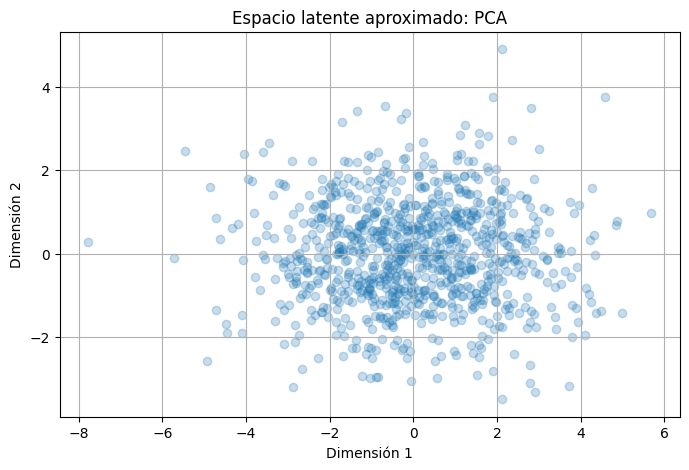

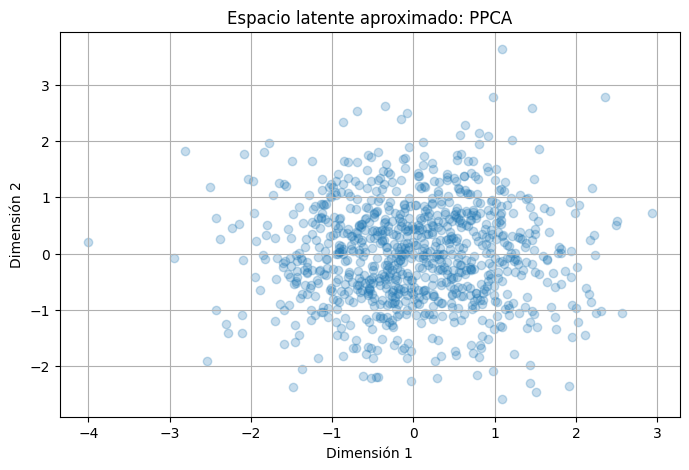

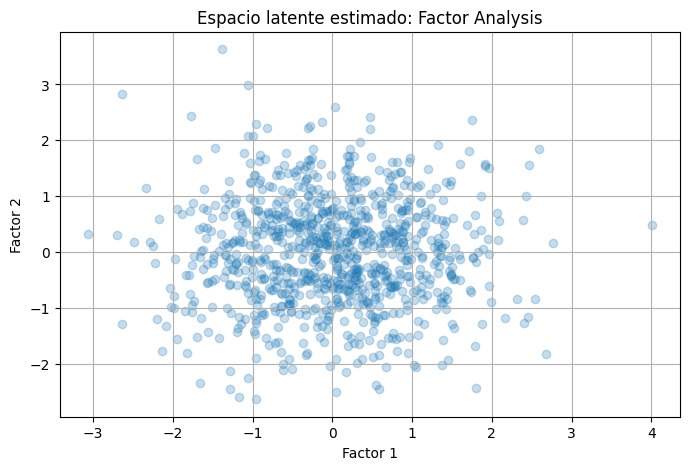

In [17]:
# @title Comparación visual de espacios latentes

plt.figure()
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], alpha=0.25)
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Espacio latente aproximado: PCA")
plt.show()

plt.figure()
plt.scatter(Z_ppca[:, 0], Z_ppca[:, 1], alpha=0.25)
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Espacio latente aproximado: PPCA")
plt.show()

plt.figure()
plt.scatter(Z_fa[:, 0], Z_fa[:, 1], alpha=0.25)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Espacio latente estimado: Factor Analysis")
plt.show()

## 11. Comparación conceptual final

| Modelo | Pregunta central | Supuesto clave | Ventaja principal | Limitación principal |
|---|---|---|---|---|
| PCA | ¿Dónde está la mayor varianza? | Componentes ortogonales | Simple, geométrico, eficiente | No separa estructura común y ruido |
| PPCA | ¿Qué factores latentes generan los datos con ruido común? | $\varepsilon \sim N(0,\sigma^2 I)$ | Probabilístico y generativo | Mismo ruido para todas las variables |
| Factor Analysis | ¿Qué factores comunes explican la dependencia entre variables? | $\varepsilon \sim N(0,\Psi)$ | Ruido específico por variable | Estimación más exigente e interpretación más sensible |

La ventaja central de Factor Analysis es que permite diferenciar entre:

$$
\text{estructura común} \quad \text{y} \quad \text{variación específica por variable}.
$$

Por eso es especialmente útil cuando las variables observadas tienen diferentes niveles de confiabilidad, precisión o ruido.

## 12. Conclusión aplicada del ejemplo

En el ejemplo de bienestar urbano, PCA permite resumir la información en pocas dimensiones. PPCA agrega una interpretación probabilística y permite hablar de factores latentes generativos.

Sin embargo, Factor Analysis es más adecuado cuando se reconoce que algunas variables son más ruidosas que otras. En este caso, variables como percepción de seguridad o actividad comercial pueden contener una mayor proporción de variabilidad específica.

Desde el punto de vista aplicado, Factor Analysis permite responder preguntas más finas:

1. ¿Qué indicadores reflejan mejor los factores comunes de bienestar urbano?
2. ¿Qué indicadores tienen demasiado ruido específico?
3. ¿Qué variables conviene revisar, medir mejor o complementar con nuevas fuentes de información?
4. ¿Qué dimensiones latentes parecen organizar el sistema urbano observado?

# 13. Taller final para resolver en clase

## Contexto del taller

Una alcaldía quiere construir un diagnóstico multivariado de zonas urbanas usando indicadores de movilidad, ambiente y percepción ciudadana. El equipo técnico desea comparar PCA, PPCA y Factor Analysis para decidir cuál modelo ofrece una lectura más útil.

Trabajen con el conjunto de datos generado en este notebook y respondan las preguntas siguientes.

## Pregunta 1

Explique brevemente qué representa una fila y qué representa una columna en la base de datos.

**Respuesta:**


## Pregunta 2

Identifique cuáles variables parecen estar relacionadas con conectividad urbana y cuáles con calidad ambiental o social.

**Respuesta:**


## Pregunta 3

Ajuste PCA con dos componentes. Interprete las cargas de PC1 y PC2. ¿Qué parece representar cada componente?

**Respuesta:**


## Pregunta 4

Observe la varianza explicada acumulada por las dos primeras componentes principales. ¿Considera que dos dimensiones son suficientes para resumir los datos? Justifique.

**Respuesta:**


## Pregunta 5

Ajuste PPCA con dos factores usando la lógica desarrollada en clase. Interprete el valor estimado de $\sigma^2$. ¿Qué representa este parámetro?

**Respuesta:**


## Pregunta 6

Explique por qué el supuesto $\varepsilon \sim N(0,\sigma^2 I)$ puede ser restrictivo en este problema.

**Respuesta:**


## Pregunta 7

Ajuste Factor Analysis con dos factores. Revise las cargas factoriales. ¿Qué interpretación puede dar a cada factor?

**Respuesta:**


## Pregunta 8

Revise las unicidades $\psi_j$. ¿Cuáles variables tienen mayor ruido específico? ¿Qué significa esto en el contexto urbano?

**Respuesta:**


## Pregunta 9

Compare PCA, PPCA y Factor Analysis. ¿Cuál modelo le parece más útil para este problema y por qué?

**Respuesta:**


## Pregunta 10

Proponga una recomendación para la alcaldía. Debe ser una conclusión breve, técnica y aplicada.

**Respuesta:**

## 14. Criterios de sustentación oral

Cada grupo tendrá máximo **5 minutos** para sustentar.

La sustentación debe responder:

1. ¿Qué estructura latente encontraron en los datos?
2. ¿Qué aportó PCA?
3. ¿Qué aportó PPCA frente a PCA?
4. ¿Qué mejora introdujo Factor Analysis frente a PPCA?
5. ¿Qué variables parecen más ruidosas o menos explicadas por los factores comunes?
6. ¿Cuál modelo recomendarían para este problema aplicado?
7. ¿Qué decisión práctica debería tomar la alcaldía con base en el análisis?

La calificación tendrá en cuenta claridad estadística, coherencia interpretativa, buen uso de las visualizaciones y capacidad para conectar el modelo con el problema aplicado.